# **End-to-End Machine Learning Project**

## Defining the Problem

---

To develop an effective machine learning model, it's critical to clearly understand its **use case** and **application context**. In this chapter, we assume the model will serve as an input to another machine learning system, alongside other signals, for predicting house prices.

### Existing Solutions and Limitations

It is equally important to evaluate the current approaches. For house pricing analysis, traditional solutions are typically implemented by statisticians using complex, rule-based methodologies. While effective, these methods often involve high costs and are time-inefficient.

### Understanding the Data Pipeline

A sequence of data processing stages is referred to as a **data pipeline**. These components often operate asynchronously, enhancing system resilience. In case of a failure in one component, its most recent output can be used as a temporary estimate, maintaining system functionality.

### Problem Type and Learning Approach

This scenario is classified as a **regression task**, requiring a **supervised learning algorithm**. Specifically:

- It is a **multivariate regression problem**, as the model will leverage multiple features to predict the target variable: the median house price.
- It is also a **univariate regression task** because only one target variable (house price) is being predicted.
- There is no continuous stream of data in this context; therefore, we are dealing with a static dataset.

### Scalability Considerations

For large datasets, there are two potential approaches to consider:

1. **Batch Learning**: Utilize distributed systems across multiple servers, leveraging frameworks such as the **MapReduce paradigm** for scalability.
2. **Online Learning**: Continuously train the model incrementally as new data becomes available.

By framing the problem with precision and understanding its nuances, we can build a robust foundation for developing the machine learning solution.

## Selecting a Performance Measure

---

For regression problems, a commonly used performance metric is the **Root Mean Square Error (RMSE)**, which is defined as:

> $$RMSE(X, h) = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left(h(x^{(i)}) - y^{(i)}\right)^2}$$

### Parameters Explanation:
- **$(m)$**: Total number of instances in the dataset.
- **$(x^{(i)})$**: Feature vector (excluding labels) of the $(i^\text{th})$ instance.
- **$(y^{(i)})$**: Actual label for the $(i^\text{th})$ instance.
- **$(X)$**: Feature matrix containing all instances, where each row corresponds to a single instance and columns represent features.
- **$(h(x^{(i)}) = \hat{y}^{(i)})$**: Predicted value for the $(i^\text{th})$ instance, computed using the **hypothesis function** $(h)$.
  
The RMSE measures the cost (error) of predictions across the dataset for a given hypothesis \(h\).

### Alternative Metric: Mean Absolute Error (MAE)
While RMSE is widely preferred in regression tasks, it is sensitive to outliers. For datasets with numerous outliers, **Mean Absolute Error (MAE)** can be a robust alternative. It is defined as:

> $$MAE(X, h) = \frac{1}{m} \sum_{i=1}^{m} \left|h(x^{(i)}) - y^{(i)}\right|$$

### Relationship with Norms
- RMSE corresponds to the **Euclidean norm** ($(L_2)$ norm).
- MAE corresponds to the **Manhattan norm** ($(L_1)$ norm).

In general, the $(L_k)$ norm of a vector $(v)$ with $(n)$ elements is defined as:

> $$||v||_k = \left(|v_1|^k + |v_2|^k + \dots + |v_n|^k \right)^{1/k}$$

### Special Cases of Norms:
- **$(L_0)$ norm**: Represents the number of non-zero elements in the vector.
- **$(L_\infty)$ norm**: Represents the maximum absolute value of elements in the vector.

### Choosing Between RMSE and MAE
- **RMSE** is more sensitive to outliers due to squaring of errors, which amplifies large deviations. However, it performs exceptionally well for datasets with a bell-shaped error distribution (Gaussian noise).
- **MAE** provides a more balanced measure when the dataset contains significant outliers, as it penalizes errors linearly.

### Practical Consideration
The choice of a performance measure should align with the characteristics of the dataset and the business problem. For instance:
- Use **RMSE** when capturing large deviations is crucial (e.g., high-precision requirements).
- Use **MAE** when the focus is on robustness against outliers.

## Check Assumptions

---

Assumptions made during data collection are critical to understand, as they directly impact the quality and relevance of the data. Documenting and validating these assumptions ensures that the dataset aligns with the intended use case.

## Acquire the Data

---

1. **Permissions and Authorizations**  
   Verify that you have the necessary permissions to access, use, and utilize the data. This includes ensuring compliance with data privacy regulations and obtaining the required access credentials.

2. **Data Sources and Formats**  
   Typically, data will be provided in a relational database, a common data storage format, or other widely-used sources. These datasets may be distributed across multiple tables, files, or documentations.

3. **Schema Familiarization**  
   Understand the structure of the data by reviewing the schema, which includes:
   - Relationships between tables or entities.
   - Field definitions, such as data types, constraints, and primary keys.
   - Any additional metadata or documentation provided by the data source.

4. **Data Accessibility**  
   Ensure that you have the necessary tools and software to query and process the data efficiently. This may involve setting up access to a database management system (DBMS) or leveraging APIs for retrieving data.

By addressing these steps, you can establish a robust foundation for working with the dataset effectively and securely.


In [20]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [21]:
def load_housing_data():
    tarball_path = Path("Data/housing.tgz")
    if not tarball_path.is_file():
        Path("Data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="Data")
    return pd.read_csv(Path("Data/housing/housing.csv"))

housing = load_housing_data()

## Quick Overview of the Data Structure

To understand the dataset structure, we can perform an initial inspection using the following methods:

### Viewing the Data
- **`head()` Method**: Displays the first 5 rows of the DataFrame, providing a quick glance at the dataset.
- **`info()` Method**: Provides a concise summary of the dataset, including:
  - Total number of rows.
  - Data types of each attribute.
  - Count of non-null values.

### Understanding Data Types
- If a column loaded from a CSV file has a data type of `object`, it is likely textual data.  
  Use the **`value_counts()` method** to identify unique categories and their counts for categorical attributes.

### Summarizing Numerical Attributes
- **`describe()` Method**: Generates a statistical summary of numerical attributes, such as mean, standard deviation, min, max, and quartiles. Null values are ignored.

### Visualizing Distributions
- **`hist()` Method**: Plots histograms for each numerical attribute in the dataset, allowing for a quick visualization of value distributions.

### Observations from the Data
1. **Median Income**:
   - The `median_income` attribute is scaled (not in USD).
   - Values are capped at **15** for higher medians and **0.5** for lower medians, scaled in units of 10,000.

2. **Capped Attributes**:
   - Other attributes, such as `housing_median_age` and `median_house_value`, are also capped.
   - Address these capped values by either:
     - Collecting additional information about the dataset's cap.
     - Excluding these instances from the training data.

3. **Skewed Distributions**:
   - Many histograms are right-skewed, indicating uneven distributions.
   - Features have vastly different scales, which might require scaling or normalization during preprocessing.

This preliminary exploration helps identify potential data issues, such as missing values, outliers, or scaling requirements, and lays the groundwork for more detailed data analysis.


In [22]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [23]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [24]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

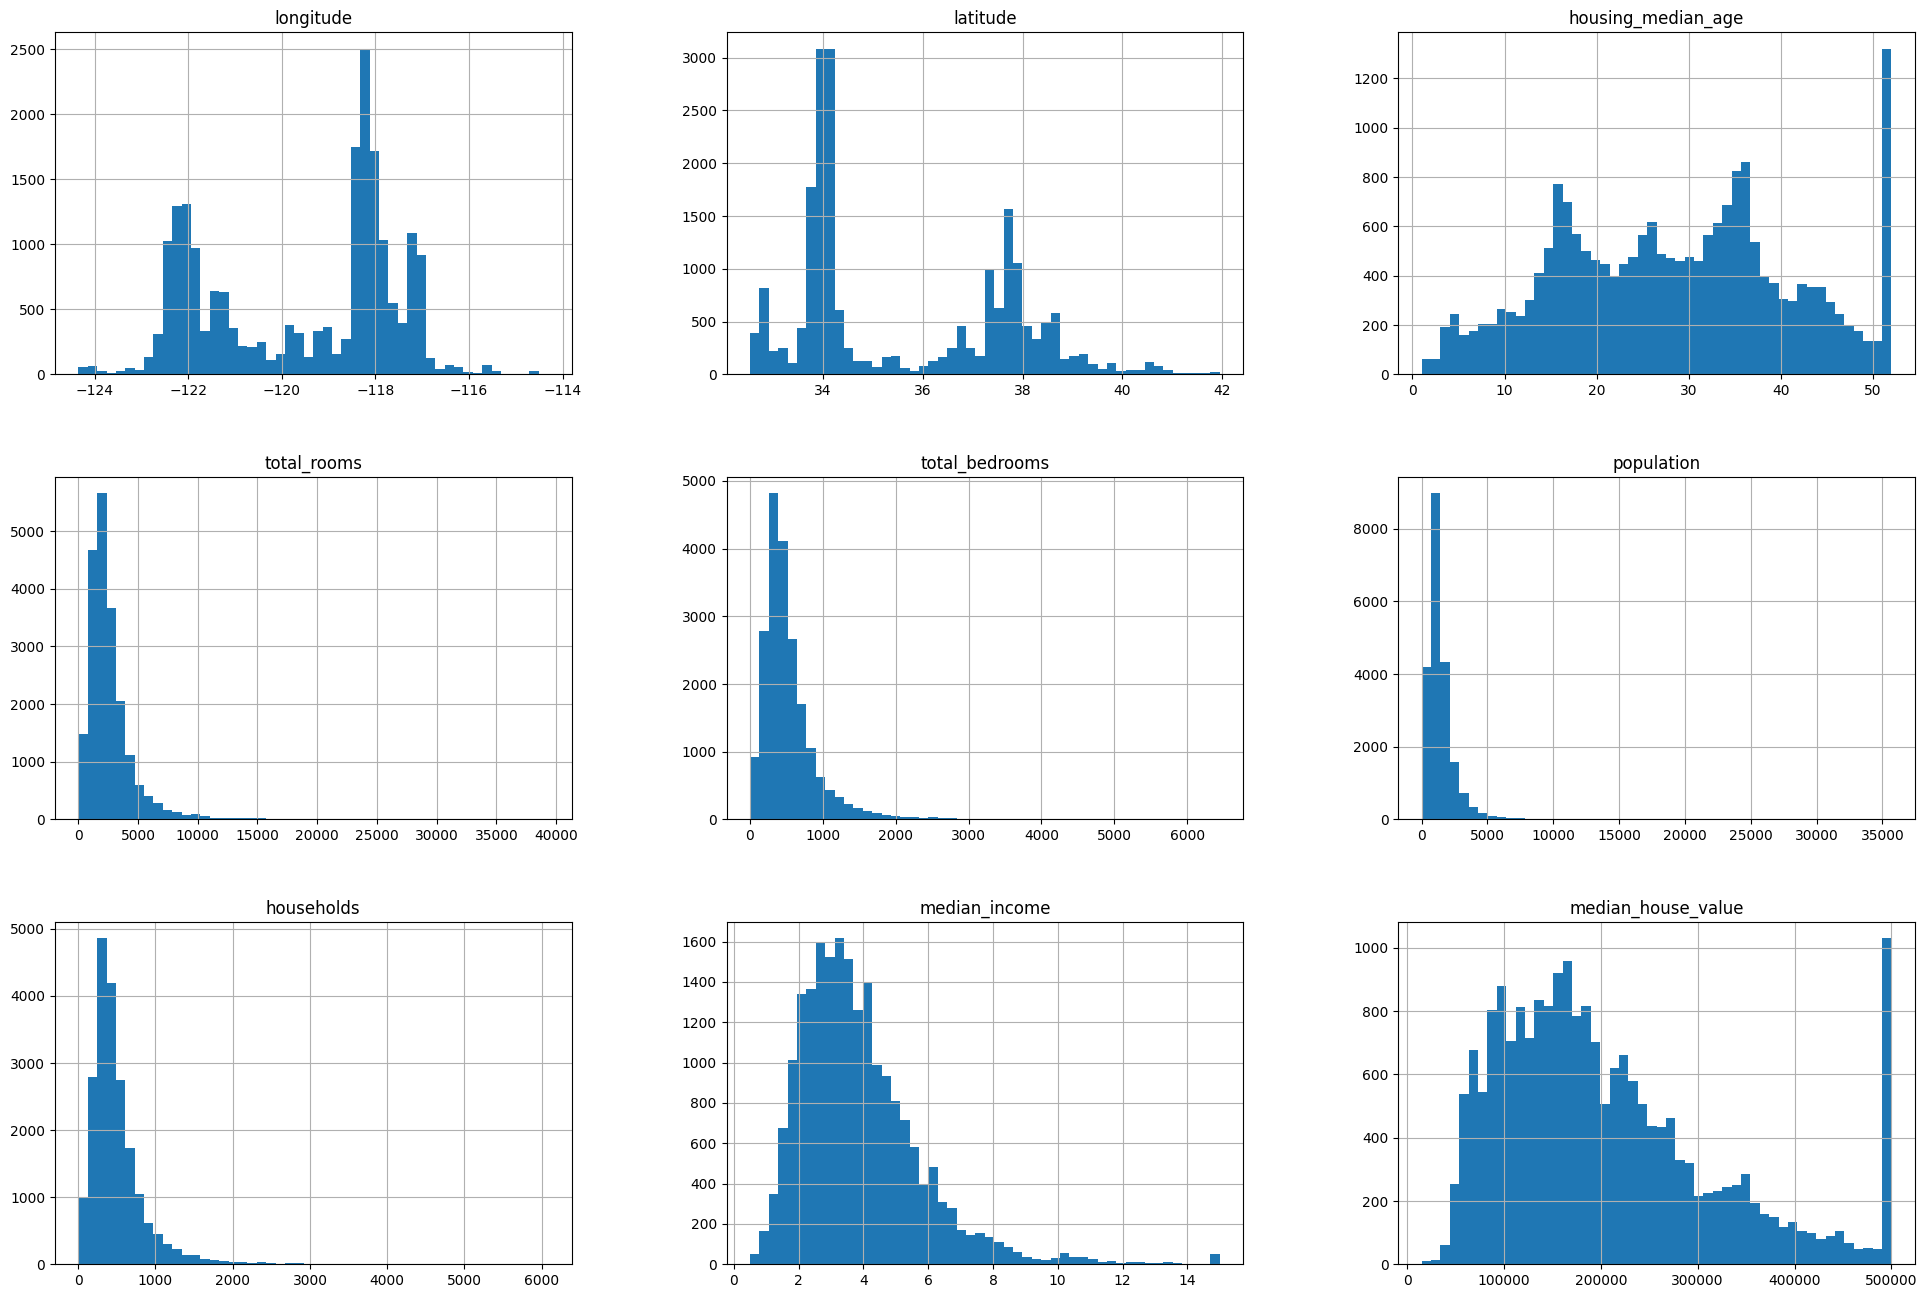

In [25]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(24,16))
plt.show()

## Creating a Test Set

When building machine learning models, our ability to recognize patterns can inadvertently introduce biases during model selection. This can lead to poor generalization on unseen data, a phenomenon known as **data snooping bias**. To mitigate this, it's essential to create a reliable test set.

### Basic Test Set Creation
A simple approach to creating a test set is to randomly set aside **20% of the data** (or a smaller percentage for larger datasets). However, this method has limitations:
1. On re-running the code, the random split generates a different test set, risking eventual exposure of the model to the entire dataset.
2. This can reduce the reliability of test set evaluation.

### Ensuring Consistency in Splits
1. **Save the Test Set Separately**: Manually save the test set to ensure it remains unchanged across runs.
2. **Random Number Generator Seed**:
   - Use a fixed random seed before splitting the dataset. For example:
     ```python
     np.random.seed(42)
     shuffled_indices = np.random.permutation(len(data))
     ```
3. **Index-Based Splitting**:
   - Use each instance's identifier to determine its placement in the train or test set.
   - If no unique identifier exists, create one using the most stable features, assuming:
     - New data is appended to the dataset.
     - No rows are deleted.
   - This method ensures that updates to the dataset don't alter the train-test split.

### Using Scikit-Learn
The **`train_test_split()` function** in Scikit-learn simplifies dataset splitting:
- The `random_state` parameter allows setting a fixed random seed, ensuring reproducible splits.
- Supports splitting multiple datasets with identical row indices.

### Addressing Sampling Bias in Small Datasets
For smaller datasets, random sampling can lead to **sampling bias**. A better approach is **stratified sampling**, which ensures that all important subgroups of the population are proportionally represented.

### Stratified Sampling Example
Suppose the **`median_income`** attribute is critical for predicting housing prices. To ensure it is well-represented:
1. **Transforming Continuous Data**:
   - Use the **`pd.cut()` function** to create an **income category attribute** with predefined bins (e.g., five categories).
     ```python
     data["income_category"] = pd.cut(
         data["median_income"],
         bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
         labels=[1, 2, 3, 4, 5]
     )
     ```
2. **Stratified Sampling**:
   - The `train_test_split()` function includes a **`stratify` argument** for stratified sampling based on an attribute.
   - Example:
     ```python
     train_set, test_set = train_test_split(data, test_size=0.2, stratify=data["income_category"], random_state=42)
     ```

### Validating Sampling Distribution
After stratified sampling, use **`value_counts()`** to verify the distribution of the categories in both the train and test sets, ensuring they represent the population proportions accurately.

### Advanced Splitting Techniques
Scikit-learn offers additional splitting tools in the **`sklearn.model_selection`** package:
- Splitters (e.g., `StratifiedShuffleSplit`) include a `split()` method that provides train-test splits by indices.
- Multiple splits allow for cross-validation and more robust performance analysis.

By employing these strategies, you can minimize data snooping bias and ensure your test set provides an accurate evaluation of model performance.

In [26]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = shuffle_and_split_data(housing, 0.2)
print(len(train_set))
print(len(test_set))

16512
4128


In [27]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio *2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id = housing.reset_index()
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

print(len(train_set))
print(len(test_set))

16512
4128


In [28]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

print(len(train_set))
print(len(test_set))

16322
4318


In [29]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

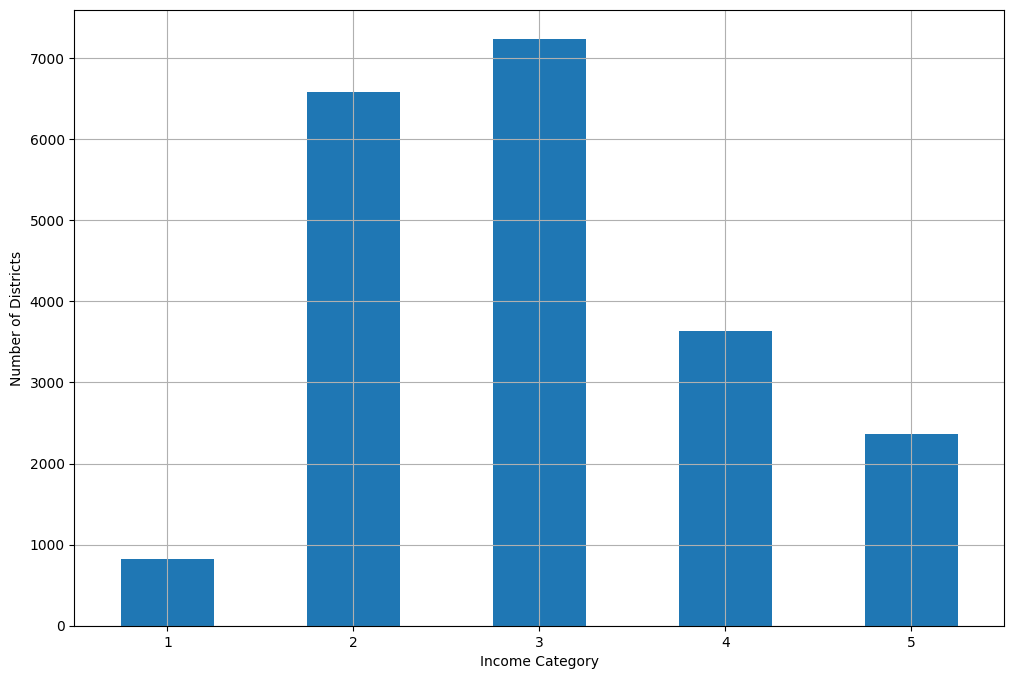

In [30]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True, figsize=(12,8))
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit

# For 10 Splits
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# Using the first split
strat_train_set, strat_test_set = strat_splits[0]

In [32]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [33]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Explore and Visualize the Data to Gain Insights

